In [1]:
from pathlib import Path

import numpy as np
from src import two_d_loader
from IPython.core.pylabtools import figsize

data_folder = Path("/Users/persie/PycharmProjects/prolley-parnell/ant-grasp-dataset")
# data_folder = Path("/Users/persie/PhD_Code/3d_ant_data_rle")

session_list = [6,10,11,13,17,19,20,21,22,23,28,29,30]
obj_ref_frame = [500,180,380,849,459, 59, 842, 24, 93, 176, 2626, 595, 241 ]
prefix = "240905-1616"
skeleton_toml_path = "skeleton.toml"
camera_list = ["strawberry", "coconut", "blueberry", "banana", "avocado"]

In [2]:
#Sessions available for CATAR
catar_session = [11, 19, 21, 29, 30]

In [3]:
from src import two_d_loader

sleap = two_d_loader.load_session("/Users/persie/Desktop/Dataset_for_upload/Data/240905-1616/inputs/tracking", session=11, use_polars=False)


Loaded 5 SLEAP slp files.


In [4]:
from src import two_d_loader
catar = two_d_loader.load_session("/Users/persie/PycharmProjects/prolley-parnell/ant-grasp-dataset/dataset/Annotation/catar/240905-1616", session=11, use_polars=False)

Loaded 1 CATAR csv files.


## Find matched keypoints between CATAR and SLEAP

Loaded 5 SLEAP slp files.
Loaded 1 CATAR csv files.
Loaded 5 SLEAP slp files.
Loaded 1 CATAR csv files.
Loaded 5 SLEAP slp files.
Loaded 1 CATAR csv files.
Loaded 5 SLEAP slp files.
Loaded 1 CATAR csv files.
Loaded 5 SLEAP slp files.
Loaded 1 CATAR csv files.


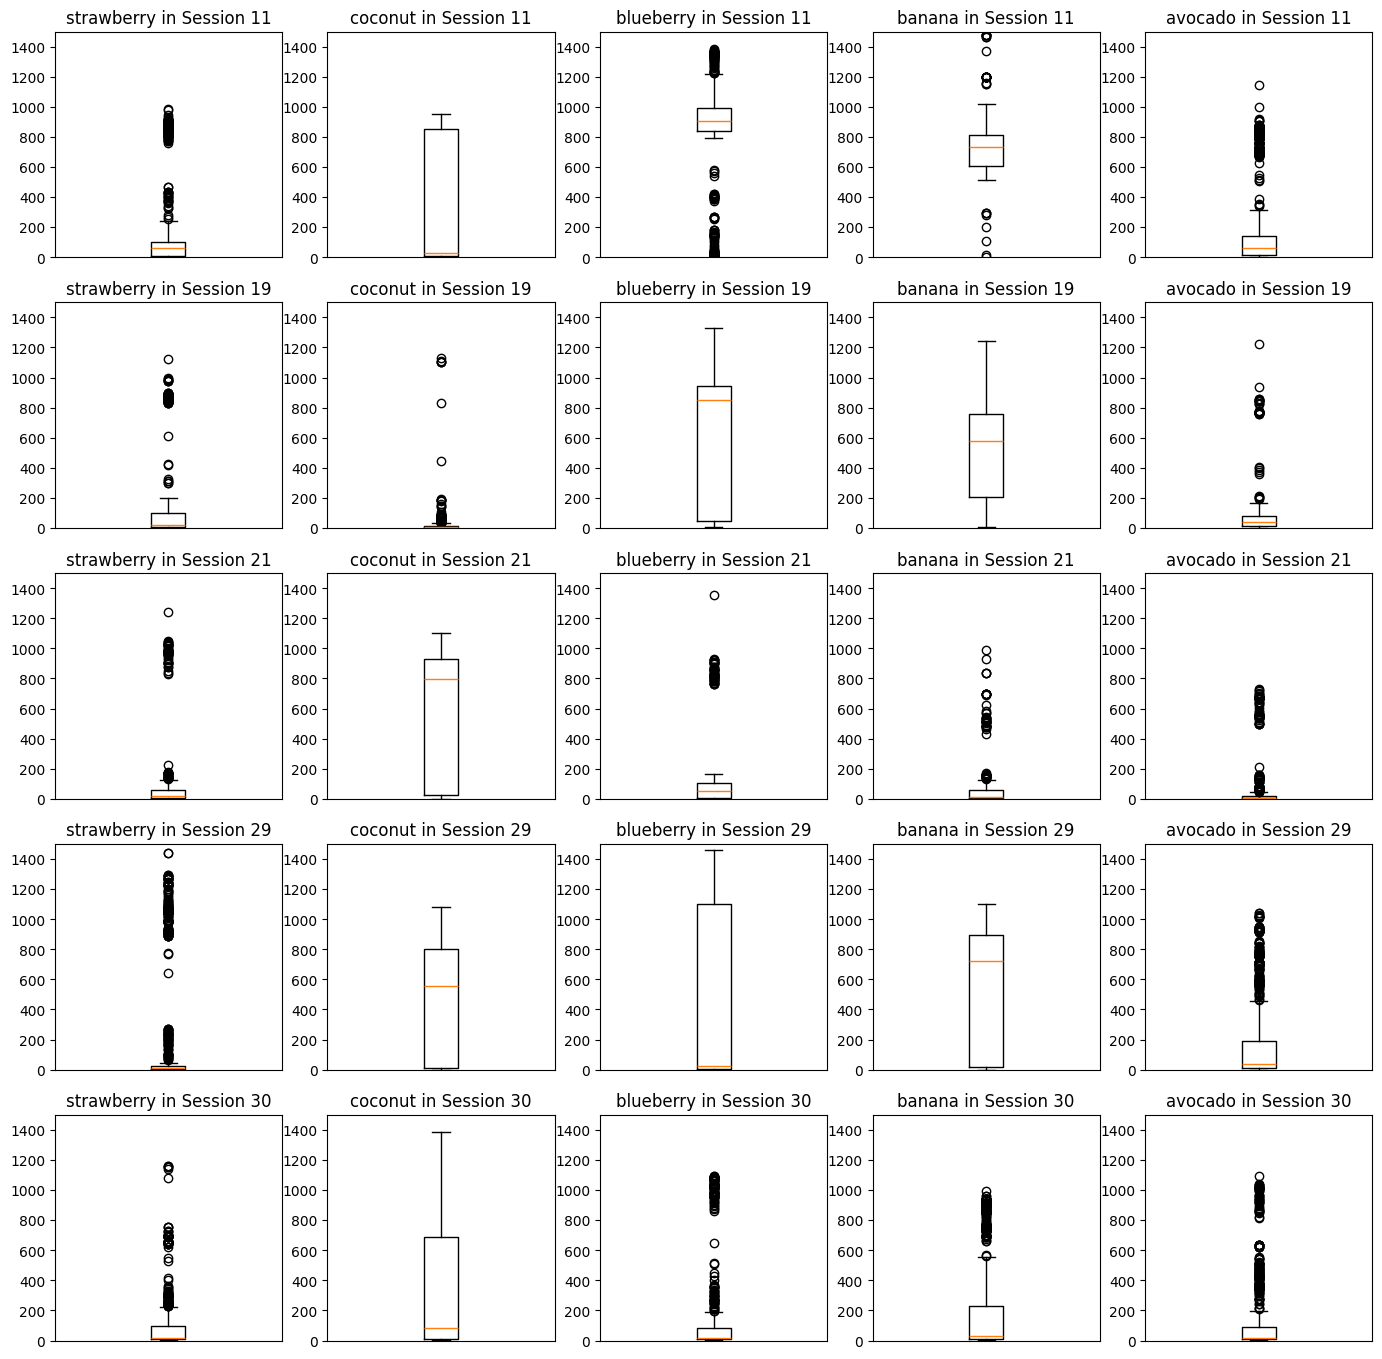

In [4]:
#Find for each keypoint in a CATAR frame
# The closest keypoint in the SLEAP frames
example_keypoints = ["a_L2", "a_R2"]

import pandas as pd
idx = pd.IndexSlice

import matplotlib.pyplot as plt
fig, ax = plt.subplots(len(camera_list), len(catar_session), figsize=(17,17))

for i, session in enumerate(catar_session):
    sleap = two_d_loader.load_session("/Users/persie/Desktop/Dataset_for_upload/Data/240905-1616/inputs/tracking", session=session, use_polars=False)
    catar = two_d_loader.load_session("/Users/persie/PycharmProjects/prolley-parnell/ant-grasp-dataset/dataset/Annotation/catar/240905-1616", session=session, use_polars=False)
    for j, camera in enumerate(camera_list):
        error_mag = []
        catar_sub = catar.xs(camera).xs("a_L2", axis=1).loc[0]
        sleap_sub = sleap.xs(camera).xs("a_L2", axis=1)
        all_sleap_frames = np.array(list(sleap_sub.index))[:,1]

        for frame in catar_sub.index:
            #Find the frame in the sleap sub that matches
            if frame in all_sleap_frames:
                matched_points = sleap_sub.loc[idx[:, frame], :].dropna()
                ref_point = catar_sub.loc[frame]
                diff = matched_points - ref_point
                if len(diff) > 0:
                    diff["mag"] = np.sqrt(diff["x"]**2 + diff["y"]**2)
                    closest_error = diff["mag"].min()
                    if not np.isnan(closest_error):
                        error_mag.append(closest_error)

        error_array = np.array(error_mag, dtype=np.float64)
        ax[i,j].boxplot(error_array)
        ax[i,j].set_title(f"{camera} in Session {session}")
        ax[i,j].set_ylim(0, 1500)
        ax[i,j].set_xticks([])



in sleap frames with multiple instances of a_l2
array([ 367,  368,  369,  535,  536,  537,  538,  540,  541,  542,  544,
        546,  547,  548,  549,  550,  551,  582,  586,  587,  589,  594,
        604,  605,  611, 2472, 2879, 2938, 2939, 2940, 2941, 2942, 2943,
       2944, 2945, 2946, 2947, 2948, 2949, 2955, 3088, 3090, 3091, 3092,
       3093, 3094, 3095, 3096, 3097, 3098, 3099, 3100, 3101, 3102, 3103,
       3104, 3105, 3106, 3107, 3108, 3109, 3110, 3111, 3112, 3113, 3968,
       4076])

<Axes: xlabel='frame'>

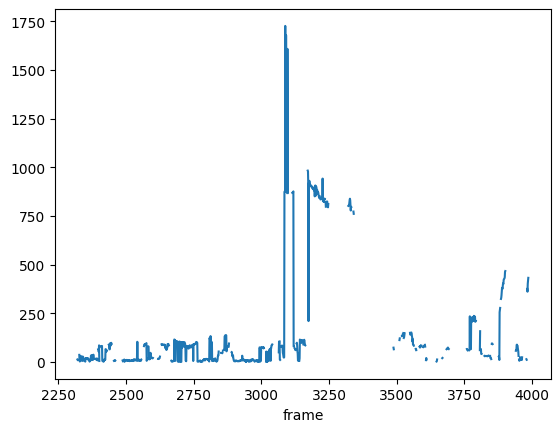

In [5]:
#find out which rows contain the frame from catar in sleap, compare all tracks and pick the closest one

#do it for a single camera for now
camera = "strawberry"

catar_sub = catar.xs(camera).xs("a_L2", axis=1).loc[0]

sleap_sub = sleap.xs(camera).xs("a_L2", axis=1)

# sleap_sub.loc[catar_sub["frame"]]
annotated_index = catar_sub.index #All the catar annotated frames

matched_frames_sleap = sleap_sub.loc(axis=0)[:, annotated_index].droplevel(level=0)

diff = catar_sub - matched_frames_sleap
import numpy as np
diff["mag"] = np.sqrt(diff["x"]**2 + diff["y"]**2)
diff.mag.plot()

## Percentage of Frames Annotated with CATAR in 2D
This is just summed across all views

In [68]:
#How many frames are there across all sessions where the keypoint is present
session_data = {}
for catar_session_name in catar_session:
    session_data[catar_session_name] = {}
    #Load the data
    catar = two_d_loader.load_session("/Users/persie/PycharmProjects/prolley-parnell/ant-grasp-dataset/dataset/Annotation/catar/240905-1616", session=catar_session_name, use_polars=False)

    total_frames = len(catar)
    session_data[catar_session_name]["total_frames"] = total_frames

    print(f"Session {catar_session_name} has {total_frames} frames")

    tracked_left = catar.loc[catar["a_L2", "score"] == 1].index
    session_data[catar_session_name]["tracked_left"] = len(tracked_left)

    print(f"Session {catar_session_name} has {len(tracked_left)} frames where a_L2 is tracked")

    tracked_right = catar.loc[catar["a_R2", "score"] == 1].index
    session_data[catar_session_name]["tracked_right"] = len(tracked_right)

    print(f"Session {catar_session_name} has {len(tracked_right)} frames where a_R2 is tracked")

    # Find instances that repeat in the tracked left and tracked right
    tracked_both = list(set(tracked_left) & set(tracked_right))
    session_data[catar_session_name]["tracked_both"] = len(tracked_both)

    print(f"Session {catar_session_name} has {len(tracked_both)} frames where the a_L2 and a_R2 are tracked")

    #For the tracked both list of tuples, count the number of occurences of each frame

    values, count = np.unique_counts(np.array(tracked_both)[:,2])

    tracked_all_view = np.nonzero(count > 4)
    session_data[catar_session_name]["tracked_all_view"] = len(tracked_all_view[0])
    print(f"Session {catar_session_name} has {len(tracked_all_view[0])} frames where the a_L2 and a_R2 are tracked in all views")


    tracked_two_view = np.nonzero(count > 1)
    session_data[catar_session_name]["tracked_two_view"] = len(tracked_two_view[0])

    print(f"Session {catar_session_name} has {len(tracked_two_view[0])} frames where the a_L2 and a_R2 are tracked in at least 2 views")

    # catar.a_R2.loc[(slice(None), slice(None), [2323])]

    session_data[catar_session_name]["percent_left"] = session_data[catar_session_name]["tracked_left"] / session_data[catar_session_name]["total_frames"] * 100

    print(f"Session {catar_session_name} has {session_data[catar_session_name]["percent_left"]}% frames where the a_L2 is tracked in at least 1 view")

    session_data[catar_session_name]["percent_right"] = session_data[catar_session_name]["tracked_right"] / session_data[catar_session_name]["total_frames"] * 100

    print(f"Session {catar_session_name} has {session_data[catar_session_name]["percent_right"]}% frames where the a_R2 is tracked in at least 1 view")

    session_data[catar_session_name]["percent_both"] = session_data[catar_session_name]["tracked_both"] / session_data[catar_session_name]["total_frames"] * 100

    print(f"Session {catar_session_name} has {session_data[catar_session_name]["percent_both"]}% frames where the a_L2 an a_R2 are tracked in at least 1 view")

    session_data[catar_session_name]["tracked_two_view"] = session_data[catar_session_name]["tracked_two_view"] / session_data[catar_session_name]["total_frames"] * 100

    print(f"Session {catar_session_name} has {session_data[catar_session_name]["tracked_two_view"]}% frames where the a_L2 and a_R2 are tracked in at least 2 views")





Loaded 1 CATAR csv files.
Session 11 has 8395 frames
Session 11 has 4178 frames where a_L2 is tracked
Session 11 has 3439 frames where a_R2 is tracked
Session 11 has 2648 frames where the a_L2 and a_R2 are tracked
Session 11 has 5 frames where the a_L2 and a_R2 are tracked in all views
Session 11 has 927 frames where the a_L2 and a_R2 are tracked in at least 2 views
Session 11 has 49.767718880285884% frames where the a_L2 is tracked in at least 1 view
Session 11 has 40.964860035735555% frames where the a_R2 is tracked in at least 1 view
Session 11 has 31.54258487194759% frames where the a_L2 an a_R2 are tracked in at least 1 view
Session 11 has 11.042287075640262% frames where the a_L2 and a_R2 are tracked in at least 2 views
Loaded 1 CATAR csv files.
Session 19 has 2905 frames
Session 19 has 2005 frames where a_L2 is tracked
Session 19 has 1462 frames where a_R2 is tracked
Session 19 has 1300 frames where the a_L2 and a_R2 are tracked
Session 19 has 9 frames where the a_L2 and a_R2 ar

In [162]:
#Work out the proportions
total_percents = {}
total_percents["total_frames"] = 0
total_percents["tracked_left"] = 0
total_percents["tracked_right"] = 0
total_percents["tracked_both"] = 0
total_percents["tracked_all_view"] = 0
total_percents["tracked_two_view"] = 0

for catar_session_name in catar_session:
    total_percents["total_frames"] += session_data[catar_session_name]["total_frames"]
    total_percents["tracked_left"] += session_data[catar_session_name]["tracked_left"]
    total_percents["tracked_right"] += session_data[catar_session_name]["tracked_right"]
    total_percents["tracked_both"] += session_data[catar_session_name]["tracked_both"]
    total_percents["tracked_all_view"] += session_data[catar_session_name]["tracked_all_view"]
    total_percents["tracked_two_view"] += session_data[catar_session_name]["tracked_two_view"]


percent_left = total_percents["tracked_left"] / total_percents["total_frames"] * 100

percent_right = total_percents["tracked_right"] / total_percents["total_frames"] * 100

percent_both = total_percents["tracked_both"] / total_percents["total_frames"] * 100

percent_all_view = total_percents["tracked_all_view"] / total_percents["total_frames"] * 100

percent_two_view = total_percents["tracked_two_view"] / total_percents["total_frames"] * 100

print(f"Total frames: {total_percents['total_frames']}")
print(f"Total frames where left is tracked: {total_percents['tracked_left']}")
print(f"Total frames where right is tracked: {total_percents['tracked_right']}")
print(f"Total frames where both are tracked: {total_percents['tracked_both']}")
print(f"Total frames where both are tracked in all views: {total_percents['tracked_all_view']}")
print(f"Total frames where both are tracked in at least 2 views: {total_percents['tracked_two_view']}")

print(f"Percent left : {percent_left}")
print(f"Percent right : {percent_right}")
print(f"Percent both : {percent_both}")
print(f"Percent all views : {percent_all_view}")
print(f"Percent two views : {percent_two_view}")


Total frames: 31865
Total frames where left is tracked: 19966
Total frames where right is tracked: 18320
Total frames where both are tracked: 14113
Total frames where both are tracked in all views: 295
Total frames where both are tracked in at least 2 views: 4637
Percent left : 62.65808881217637
Percent right : 57.49254668131179
Percent both : 44.28997332496469
Percent all views : 0.9257806370626078
Percent two views : 14.55201631884513


## Get CATAR Keypoint velocity

In [3]:
from pandas import DataFrame
import logging
logger = logging.getLogger(__name__)
#Define function to incrementally calculate the velocity across frames
def get_motion_df(catar_dataframe, kp_in_df) -> (DataFrame, DataFrame, DataFrame, DataFrame, list[str]) :
    """
    From the position dataframe, calculate the displacement, velocity and acceleration and return all as dataframes
    :return: position_df, displace_df, velocity_df, acceleration_df, kp_in_df, list of node names
    """
    #This should be the frames only with the associated keypoint
    position_df = catar_dataframe.T
    keys = sorted(position_df.keys())

    displace_df = DataFrame(dtype=np.float64, columns=position_df[keys].columns, index=position_df[keys].index)
    velocity_df = DataFrame(dtype=np.float64).reindex_like(position_df[keys])
    acceleration_df = DataFrame(dtype=np.float64).reindex_like(position_df[keys])

    for kp in kp_in_df:
        # u = 0
        for key in keys:
            key_upper = key + 1

            p_start = position_df.loc[kp, key] #Add x, y to squish together
            if not p_start.isnull().any():
                if position_df.keys().__contains__(key_upper):
                    p_end = position_df.loc[kp, key_upper]
                    if not p_end.isnull().any():
                        s = np.asarray(p_end - p_start, dtype=np.float64)
                        dt = (key_upper - key)/100 #100fps
                        v = np.asarray(s / dt, dtype=np.float64)

                        if velocity_df.keys().__contains__(key - 1):
                            u = velocity_df.loc[kp, key - 1]
                            dt = 0.01 #100FPS
                        else:
                            u = np.nan
                        a = np.asarray((v - u) / dt, dtype=np.float64)

                        displace_df.at[kp, key] = s
                        acceleration_df.at[kp, key] = a
                        velocity_df.at[kp, key] = v

                    else:
                        logger.info(f"End point is invalid: Node: {kp}, Frame: {key_upper}")
            else:
                logger.info(f"Starting point is invalid: Node: {kp}, Frame: {key}")

    return position_df, displace_df, velocity_df, acceleration_df, kp_in_df

def xyz_to_mag_df(dataframe_in: DataFrame, node_list: list[str] = None) -> DataFrame:
    """ Convert a dataframe generated in the xyz into a magnitude dataframe """
    if node_list is None:
        node_list = dataframe_in.index.levels[0]
    keys = dataframe_in.keys()
    dataframe_out = DataFrame(dtype=np.float64, index=node_list, columns=keys)

    for key in keys:
        for kp in node_list:
            xyz = dataframe_in.loc[kp, key].drop("score")
            if not xyz.isnull().any():
                dataframe_out.loc[kp, key] = np.linalg.norm(xyz).astype(np.float64)

    return dataframe_out

kp_list = ["a_L2", "a_R2"]
full_data_catar = []
for i, session in enumerate(catar_session):

    catar = two_d_loader.load_session("/Users/persie/PycharmProjects/prolley-parnell/ant-grasp-dataset/dataset/Annotation/catar/240905-1616", session=session, use_polars=False)
    for j, camera in enumerate(camera_list):
        catar_camera_df = catar.xs(camera).droplevel("track")


        # for kp in list(catar_camera_df.keys().levels[0]):
        #     if kp not in ["camera", "comments", "frame", "track"]:
        #         kp_list.append(kp)

        position_df, displace_df, velocity_df, acceleration_df, kp_in_df = get_motion_df(catar_camera_df[kp_list], kp_list)

        velocity_mag = xyz_to_mag_df(velocity_df, kp_list)
        full_data_catar.append(velocity_mag.values)



Loaded 1 CATAR csv files.
Loaded 1 CATAR csv files.
Loaded 1 CATAR csv files.
Loaded 1 CATAR csv files.
Loaded 1 CATAR csv files.


## Plot the CATAR velocity in pixels per second

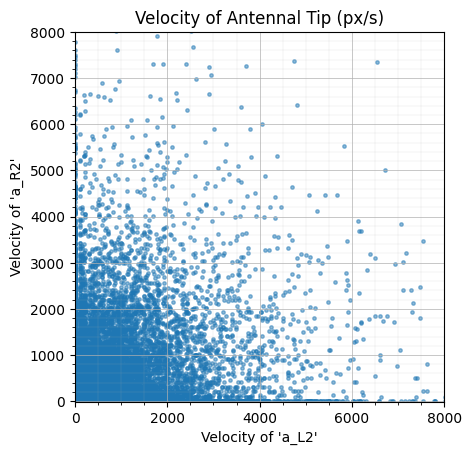

In [4]:
#Append the velocities as pairs to an array then plot the scatter array
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'
# full_data_np = np.array(full_data)
catar_velocity_mag = np.concat(full_data_catar, axis=1)
Z = catar_velocity_mag[:, np.all(~np.isnan(catar_velocity_mag), axis=0)]
Z_catar = Z

fig, ax = plt.subplots()
plt.title("Velocity of Antennal Tip (px/s)")
ax.scatter(Z[0, :], Z[1, :], marker='o', s=6, alpha=0.5)
ax.set_xlabel("Velocity of 'a_L2'")
ax.set_ylabel("Velocity of 'a_R2'")
ax.set_aspect('equal', adjustable='box')
ax.set_xlim(-10, 8000)
ax.set_ylim(-10, 8000)
ax.grid(visible=True, which='major', linestyle='-', linewidth=0.5)
ax.grid(visible=True, which='minor', linestyle='-', linewidth=0.1)
ax.minorticks_on()

# x1, x2, y1, y2 = (0, 50, 0, 50)  # subregion of the original image
# axins = ax.inset_axes(
#     [0.5, 0.5, 0.47, 0.47],
#     xlim=(x1, x2), ylim=(y1, y2))
# axins.grid(visible=True, which='major', linestyle='-', linewidth=0.5)
# axins.grid(visible=True, which='minor', linestyle='-', linewidth=0.1)
# axins.scatter(Z2.loc["a_L2"], Z2.loc["a_R2"], marker='o', s=6, alpha=0.5)
# axins.set_xlim(0, 50)
# axins.set_ylim(0, 50)
# axins.set_xticks([0, 10, 20, 30, 40, 50])



# ax.indicate_inset_zoom(axins, edgecolor="black", linewidth=2)
# plt.savefig("/Users/persie/Library/CloudStorage/OneDrive-UniversityofEdinburgh/PhD/Figures/Thesis Figures/Experiment Analysis/antenna_velocity_inset.svg")
plt.show()

In [5]:
#clean up non-paired points
clean_velocity = Z_catar
covar = np.cov(clean_velocity[0, :], clean_velocity[1, :])
correlation = np.corrcoef(clean_velocity[0, :], clean_velocity[1, :])
print(correlation)
print(covar)

[[1.         0.04060462]
 [0.04060462 1.        ]]
[[1.23451885e+08 4.85982858e+06]
 [4.85982858e+06 1.16036157e+08]]


## Percentage of Frames Annotated with SLEAP in 2D
This is just summed across all views

In [67]:
#How many frames are there across all sessions where the keypoint is present
session_data = {}
for catar_session_name in catar_session:
    session_data[catar_session_name] = {}
    #Load the data
    sleap = two_d_loader.load_session("/Users/persie/Desktop/Dataset_for_upload/Data/240905-1616/inputs/tracking", session=catar_session_name, use_polars=False)

    total_frames = len(sleap)
    session_data[catar_session_name]["total_frames"] = total_frames

    print(f"Session {catar_session_name} has {total_frames} frames")

    tracked_left = sleap.loc[sleap["a_L2", "score"] > 0.0].index
    session_data[catar_session_name]["tracked_left"] = len(tracked_left)

    print(f"Session {catar_session_name} has {len(tracked_left)} frames where a_L2 is tracked")

    tracked_right = sleap.loc[sleap["a_R2", "score"] > 0.0].index
    session_data[catar_session_name]["tracked_right"] = len(tracked_right)

    print(f"Session {catar_session_name} has {len(tracked_right)} frames where a_R2 is tracked")

    # Find instances that repeat in the tracked left and tracked right
    tracked_both = list(set(tracked_left) & set(tracked_right))
    session_data[catar_session_name]["tracked_both"] = len(tracked_both)

    print(f"Session {catar_session_name} has {len(tracked_both)} frames where the a_L2 and a_R2 are tracked")

    #For the tracked both list of tuples, count the number of occurences of each frame

    values, count = np.unique_counts(np.array(tracked_both)[:,2])

    tracked_all_view = np.nonzero(count > 4)
    session_data[catar_session_name]["tracked_all_view"] = len(tracked_all_view[0])
    print(f"Session {catar_session_name} has {len(tracked_all_view[0])} frames where the a_L2 and a_R2 are tracked in all views")


    tracked_two_view = np.nonzero(count > 1)
    session_data[catar_session_name]["tracked_two_view"] = len(tracked_two_view[0])

    print(f"Session {catar_session_name} has {len(tracked_two_view[0])} frames where the a_L2 and a_R2 are tracked in at least 2 views")

    # catar.a_R2.loc[(slice(None), slice(None), [2323])]

    session_data[catar_session_name]["percent_left"] = session_data[catar_session_name]["tracked_left"] / session_data[catar_session_name]["total_frames"] * 100

    print(f"Session {catar_session_name} has {session_data[catar_session_name]["percent_left"]}% frames where the a_L2 is tracked in at least 1 view")

    session_data[catar_session_name]["percent_right"] = session_data[catar_session_name]["tracked_right"] / session_data[catar_session_name]["total_frames"] * 100

    print(f"Session {catar_session_name} has {session_data[catar_session_name]["percent_right"]}% frames where the a_R2 is tracked in at least 1 view")

    session_data[catar_session_name]["percent_both"] = session_data[catar_session_name]["tracked_both"] / session_data[catar_session_name]["total_frames"] * 100

    print(f"Session {catar_session_name} has {session_data[catar_session_name]["percent_both"]}% frames where the a_L2 an a_R2 are tracked in at least 1 view")

    session_data[catar_session_name]["tracked_two_view"] = session_data[catar_session_name]["tracked_two_view"] / session_data[catar_session_name]["total_frames"] * 100

    print(f"Session {catar_session_name} has {session_data[catar_session_name]["tracked_two_view"]}% frames where the a_L2 and a_R2 are tracked in at least 2 views")



Loaded 5 SLEAP slp files.
Session 11 has 13283 frames
Session 11 has 5806 frames where a_L2 is tracked
Session 11 has 3392 frames where a_R2 is tracked
Session 11 has 2174 frames where the a_L2 and a_R2 are tracked
Session 11 has 0 frames where the a_L2 and a_R2 are tracked in all views
Session 11 has 553 frames where the a_L2 and a_R2 are tracked in at least 2 views
Session 11 has 43.71000526989385% frames where the a_L2 is tracked in at least 1 view
Session 11 has 25.536399909658964% frames where the a_R2 is tracked in at least 1 view
Session 11 has 16.36678461190996% frames where the a_L2 an a_R2 are tracked in at least 1 view
Session 11 has 4.163216140932018% frames where the a_L2 and a_R2 are tracked in at least 2 views
Loaded 5 SLEAP slp files.
Session 19 has 4342 frames
Session 19 has 2373 frames where a_L2 is tracked
Session 19 has 1481 frames where a_R2 is tracked
Session 19 has 1097 frames where the a_L2 and a_R2 are tracked
Session 19 has 0 frames where the a_L2 and a_R2 are

## Get SLEAP Keypoint velocity

## Find the correlation and covariance for the SLEAP kp that are closest to the CATAR annotations

In [6]:
#Find for each keypoint in a CATAR frame
# The closest keypoint in the SLEAP frames
import pandas as pd
from pandas import DataFrame
import logging
logger = logging.getLogger(__name__)

def get_motion_df(sleap_dataframe, kp_in_df) -> (DataFrame, DataFrame, DataFrame, DataFrame, list[str]) :
    """
    From the position dataframe, calculate the displacement, velocity and acceleration and return all as dataframes
    :return: position_df, displace_df, velocity_df, acceleration_df, kp_in_df, list of node names
    """
    #This should be the frames only with the associated keypoint
    position_df = sleap_dataframe.T
    keys = list(set(sorted(position_df.keys())))

    displace_df = DataFrame(dtype=np.float64, columns=keys, index=position_df[keys].index)
    velocity_df = DataFrame(dtype=np.float64).reindex_like(displace_df[keys])
    acceleration_df = DataFrame(dtype=np.float64).reindex_like(displace_df[keys])

    for kp in kp_in_df:
        # u = 0
        for key in keys:
            key_upper = key + 1

            p_start_w_na = position_df.loc[kp, key] #Add x, y to squish together
            if isinstance(p_start_w_na, pd.Series):
                p_start=p_start_w_na.dropna()
            else:
                p_start=p_start_w_na.dropna(axis="columns").squeeze()

            if len(p_start) > 0:
                if position_df.keys().__contains__(key_upper):
                    p_end_w_na = position_df.loc[kp, key_upper]
                    if isinstance(p_end_w_na, pd.Series):
                        p_end=p_end_w_na.dropna()
                    else:
                        p_end=p_end_w_na.dropna(axis="columns").squeeze()
                    if len(p_end) > 0:
                        s = np.asarray(p_end - p_start, dtype=np.float64)
                        dt = (key_upper - key)/100 #100fps
                        v = np.asarray(s / dt, dtype=np.float64)

                        if velocity_df.keys().__contains__(key - 1):
                            u = velocity_df.loc[kp, key - 1]
                            dt = 0.01 #100FPS
                        else:
                            u = np.nan
                        a = np.asarray((v - u) / dt, dtype=np.float64)

                        displace_df.loc[kp, key] = s
                        acceleration_df.at[kp, key] = a
                        velocity_df.at[kp, key] = v

                    else:
                        logger.info(f"End point is invalid: Node: {kp}, Frame: {key_upper}")
            else:
                logger.info(f"Starting point is invalid: Node: {kp}, Frame: {key}")

    return position_df, displace_df, velocity_df, acceleration_df, kp_in_df

def xyz_to_mag_df(dataframe_in: DataFrame, node_list: list[str] = None) -> DataFrame:
    """ Convert a dataframe generated in the xyz into a magnitude dataframe """
    if node_list is None:
        node_list = dataframe_in.index.levels[0]
    keys = dataframe_in.keys()
    dataframe_out = DataFrame(dtype=np.float64, index=node_list, columns=keys)

    for key in keys:
        for kp in node_list:
            xyz = dataframe_in.loc[kp, key]
            if not xyz.isnull().any():
                dataframe_out.loc[kp, key] = np.linalg.norm(xyz).astype(np.float64)

    return dataframe_out



example_keypoints = ["a_L2", "a_R2"]
import pandas as pd
idx = pd.IndexSlice
full_velocity_data_sleap = []
for i, session in enumerate(catar_session):

    sleap = two_d_loader.load_session("/Users/persie/Desktop/Dataset_for_upload/Data/240905-1616/inputs/tracking", session=session, use_polars=False)
    catar = two_d_loader.load_session("/Users/persie/PycharmProjects/prolley-parnell/ant-grasp-dataset/dataset/Annotation/catar/240905-1616", session=session, use_polars=False)
    for j, camera in enumerate(camera_list):
        catar_this_view = catar.xs(camera)
        sleap_this_view = sleap.xs(camera)
        catar_frames = catar_this_view.index
        sleap_frames = np.array(list(sleap_this_view.index))[:,1]

        #List of instances to use
        instance_list = []


        for frame in catar_frames:
            #Find the frame in the sleap sub that matches
            if frame[1] in sleap_frames:
                # output_data[frame[1]] = {}
                for kp in example_keypoints:
                    ref_point = catar_this_view.loc[frame][kp]
                    if ref_point["score"] > 0:
                        matched_points = sleap_this_view.xs(kp, axis=1).loc[idx[:, frame[1], :]].dropna()

                        if len(matched_points) > 0:
                            matched_points["diff_x"] = matched_points["x"] - ref_point["x"]
                            matched_points["diff_y"] = matched_points["y"] - ref_point["y"]
                            matched_points["mag"] = np.sqrt(matched_points["diff_x"]**2 + matched_points["diff_y"]**2)
                            closest_error = matched_points["mag"].min()
                            smallest = matched_points["mag"].idxmin()

                            instance_list.append([smallest, frame[1], kp])

        #Make a sub-dataframe of all the matched instances for left and right
        instance_array = np.array(instance_list)
        mi = pd.MultiIndex.from_tuples(list(set([(i[0].astype(int), i[1].astype(int)) for i in instance_array])), names=["track", "frame"])
        output_position_dataframe = pd.DataFrame(index=mi, columns=pd.MultiIndex.from_product([example_keypoints, ["x", "y"]]))
        for instance in instance_list:
            output_position_dataframe.loc[(instance[0], instance[1]), (instance[2], ["x", "y"])] = sleap_this_view.loc[
    (instance[0], instance[1]), (instance[2], ["x", "y"])]

        without_track = output_position_dataframe.droplevel(0, axis=0)
        #Find the velocity of those instances
        position_df, displace_df, velocity_df, acceleration_df, kp_in_df = get_motion_df(without_track, example_keypoints)
        velocity_mag = xyz_to_mag_df(velocity_df, kp_in_df)

        #Append those velocities to a list
        full_velocity_data_sleap.append(velocity_mag.values)





Loaded 5 SLEAP slp files.
Loaded 1 CATAR csv files.
Loaded 5 SLEAP slp files.
Loaded 1 CATAR csv files.
Loaded 5 SLEAP slp files.
Loaded 1 CATAR csv files.
Loaded 5 SLEAP slp files.
Loaded 1 CATAR csv files.
Loaded 5 SLEAP slp files.
Loaded 1 CATAR csv files.


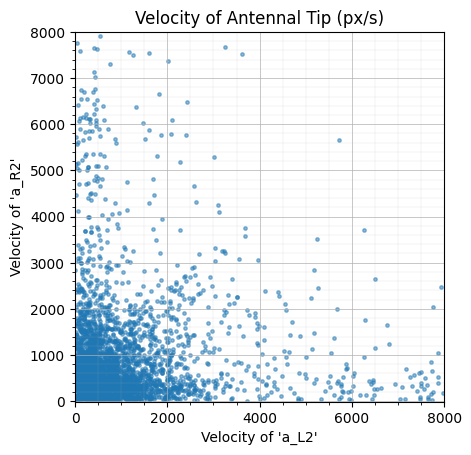

In [7]:
#Append the velocities as pairs to an array then plot the scatter array
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

sleap_velocity_mag = np.concat(full_velocity_data_sleap, axis=1)
Z = sleap_velocity_mag[:, (~np.isnan(sleap_velocity_mag)).all(axis=0)]
Z_sleap = Z

fig, ax = plt.subplots()
plt.title("Velocity of Antennal Tip (px/s)")
ax.scatter(Z[0, :], Z[1, :], marker='o', s=6, alpha=0.5)
ax.set_xlabel("Velocity of 'a_L2'")
ax.set_ylabel("Velocity of 'a_R2'")
ax.set_aspect('equal', adjustable='box')
ax.set_xlim(-10, 8000)
ax.set_ylim(-10, 8000)
ax.grid(visible=True, which='major', linestyle='-', linewidth=0.5)
ax.grid(visible=True, which='minor', linestyle='-', linewidth=0.1)
ax.minorticks_on()

# x1, x2, y1, y2 = (0, 50, 0, 50)  # subregion of the original image
# axins = ax.inset_axes(
#     [0.5, 0.5, 0.47, 0.47],
#     xlim=(x1, x2), ylim=(y1, y2))
# axins.grid(visible=True, which='major', linestyle='-', linewidth=0.5)
# axins.grid(visible=True, which='minor', linestyle='-', linewidth=0.1)
# axins.scatter(Z2.loc["a_L2"], Z2.loc["a_R2"], marker='o', s=6, alpha=0.5)
# axins.set_xlim(0, 50)
# axins.set_ylim(0, 50)
# axins.set_xticks([0, 10, 20, 30, 40, 50])



# ax.indicate_inset_zoom(axins, edgecolor="black", linewidth=2)
# plt.savefig("/Users/persie/Library/CloudStorage/OneDrive-UniversityofEdinburgh/PhD/Figures/Thesis Figures/Experiment Analysis/antenna_velocity_inset.svg")
plt.show()

In [8]:
#clean up non-paired points
clean_velocity = Z_sleap
covar = np.cov(clean_velocity[0, :], clean_velocity[1, :])
correlation = np.corrcoef(clean_velocity[0, :], clean_velocity[1, :])
print(correlation)
print(covar)

[[1.         0.11566607]
 [0.11566607 1.        ]]
[[18822360.77044938  1864221.23997429]
 [ 1864221.23997429 13800946.35854292]]
